# Analizando la Rotación de Clientes en Telecomunicaciones

## Requisitos

Tu tarea es limpiar y explorar un dataset para los ejecutivos de una empresa de telecomunicaciones que describe tendencias en la rotación de sus clientes.

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#CREAMOS DATAFRAME
df = pd.read_csv('telco.csv')

In [3]:
#VEMOS DIMENSIONES 
df.shape

(7043, 21)

In [4]:
#REVISAR PRIMERAS Y ULTIMA FILAS
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



=== Ultimas 5 filas ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
#REVISAR COLUMNAS, TIPOS Y POTENCIALES NULOS
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Limpieza de datos con Python:
* Identificar y solucionar cualquier valor duplicado.
* Asegurarse de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
* Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).
* Identificar y solucionar cualquier valor faltante en el dataset. Rellenar los valores faltantes con un marcador adecuado para el tipo de dato.
* Identificar y solucionar cualquier punto de dato inapropiado o inusual (ejemplo: la edad no puede ser 325).

In [7]:
# VALORES DUPLICADOS
print('=== Valores duplicados en el set ===')
display(df.duplicated().sum())
print('\n=== Verificar si existe algun Customer ID duplicado ===')
display(df.duplicated(subset=['customerID']).sum())

=== Valores duplicados en el set ===


np.int64(0)


=== Verificar si existe algun Customer ID duplicado ===


np.int64(0)

In [6]:
#CAMBIAR EL TIPO DE DATOS DE LA COLUMNA TOTAL CHARGES A NUMERICO
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
#REVISAR EL EFECTO DEL CAMBIO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
#COMO CAMBIAR EL TIPO DE LA COLUMNA, GENERO 11 VALORES NULOS, SE ELIMINAN DE LOS DATOS
df.dropna(inplace=True)

In [10]:
#SE CREA UN DICCIONARIO CON LOS VALORES UNICOS PARA CADA COLUMNA DEL DATAFRAME 
unique_dict = {col: df[col].unique() for col in df}
unique_dict

{'customerID': array(['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', ..., '4801-JZAZL',
        '8361-LTMKD', '3186-AJIEK'], shape=(7032,), dtype=object),
 'gender': array(['Female', 'Male'], dtype=object),
 'SeniorCitizen': array([0, 1]),
 'Partner': array(['Yes', 'No'], dtype=object),
 'Dependents': array(['No', 'Yes'], dtype=object),
 'tenure': array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
        21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
         9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
        36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
        54, 51, 26, 39]),
 'PhoneService': array(['No', 'Yes'], dtype=object),
 'MultipleLines': array(['No phone service', 'No', 'Yes'], dtype=object),
 'InternetService': array(['DSL', 'Fiber optic', 'No'], dtype=object),
 'OnlineSecurity': array(['No', 'Yes', 'No internet service'], dtype=object),
 'OnlineBackup': array(['Yes', 'No', 'No internet 

In [11]:
#SE CREA UNA NUEVA COLUMNA LLAMADA CantServicios QUE MUESTRE LA CANTIDAD DE SERVICIOS CONTRATADOS
# ESTO SE HACE SUMANDO LOS 'Yes' DE LA COLUMNA 6 A LA 14
df['CantServicios'] = (df.iloc[:, 5:15] == 'Yes').sum(axis=1)

In [12]:
# REALIZAMOS ESTADISTICA DESCRIPTIVA DE LAS COLUMNAS DEL DATAFRAME
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))

=== Columnas numericas ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CantServicios
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,3.363339
std,0.368844,24.545260,30.085974,2266.771362,2.062067
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,1.000000
50%,0.000000,29.000000,70.350000,1397.475000,3.000000
75%,0.000000,55.000000,89.862500,3794.737500,5.000000
max,1.000000,72.000000,118.750000,8684.800000,8.000000



=== Columnas categoricas ===


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


## Exploración de datos con Python:
* Crear dos tipos diferentes de visualizaciones exploratorias univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.
* Crear dos tipos diferentes de visualizaciones exploratorias multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

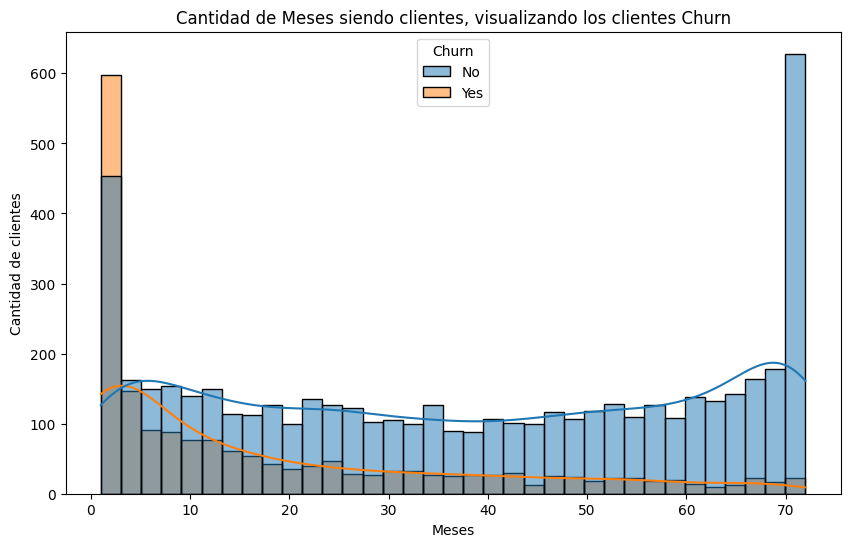

In [54]:
# COMO LA IDEA ES RETENER CLIENTES O EVALUAR EL "CHURN", SE GRAFICAN LOS MESES QUE LLEVAN EN LA COMPAÑIA
plt.figure(figsize=(10, 6))

sns.histplot(data=df,x='tenure', hue='Churn', bins=35, kde=True)

plt.title("Cantidad de Meses siendo clientes, visualizando los clientes Churn")
plt.xlabel("Meses")
plt.ylabel("Cantidad de clientes")
plt.show()

---
* EL grafico nos muestra que existe una alta ida de clientes o 'Churn' durante los primeros 18 meses. 
* EL grafico nos muestra que cerca de los 20 meses, la posibilidad de ser un cliente que deje la empresa baja considerablemente mientras mas tiempo pasa
---

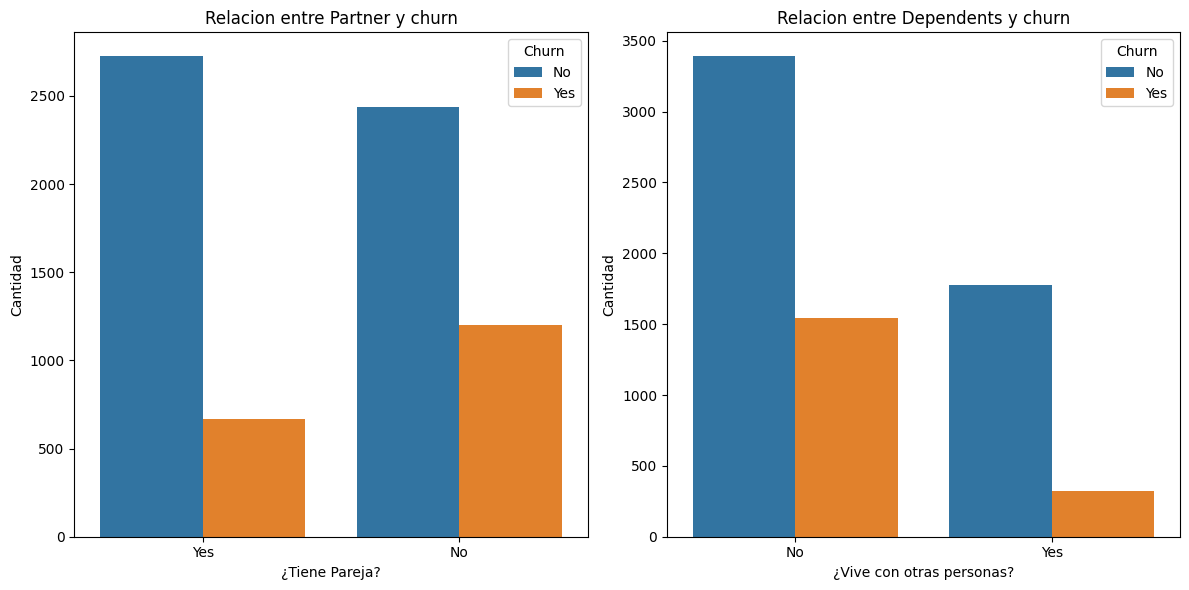

In [20]:
#RELACION ENTRE CHURN Y VARIABLES FAMILIARES (SI CLIENTE TIENE PAREJA O SI VIVE CON MAS PERSONAS)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(x='Partner', hue='Churn', data=df, ax=axes[0])
axes[0].set_title('Relacion entre Partner y churn')
axes[0].set_xlabel('¿Tiene Pareja?')
axes[0].set_ylabel('Cantidad')

sns.countplot(x='Dependents', hue='Churn', data=df, ax=axes[1])
axes[1].set_title('Relacion entre Dependents y churn')
axes[1].set_xlabel('¿Vive con otras personas?')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

---
* Se observa menos clientes 'Churn' cuando tienen una pareja
* Tambien se observa una mas baja posibilidad de dejar la compañia, si vive con mas personas
---

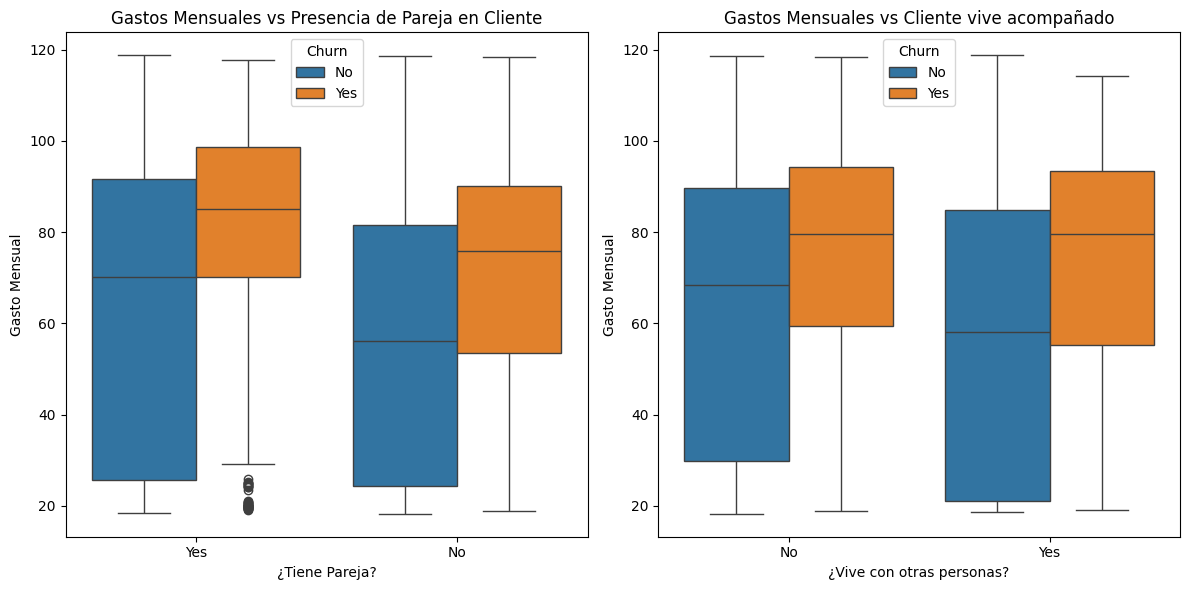

In [27]:
#Relacion entre Churn y variables familiares
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='Partner', y='MonthlyCharges', data=df, hue='Churn', ax=axes[0])
axes[0].set_title('Gastos Mensuales vs Presencia de Pareja en Cliente')
axes[0].set_xlabel('¿Tiene Pareja?')
axes[0].set_ylabel('Gasto Mensual')

sns.boxplot(x='Dependents', y='MonthlyCharges', data=df, hue='Churn', ax=axes[1])
axes[1].set_title('Gastos Mensuales vs Cliente vive acompañado')
axes[1].set_xlabel('¿Vive con otras personas?')
axes[1].set_ylabel('Gasto Mensual')

plt.tight_layout()
plt.show()

---
* No solamente que un cliente tenga pareja y viva con mas personas, indica menores posibilidades de 'Churn', sino que ademas, la mediana de pago mensual es mas elevado, aunque no sea un diferencia significativa.
---

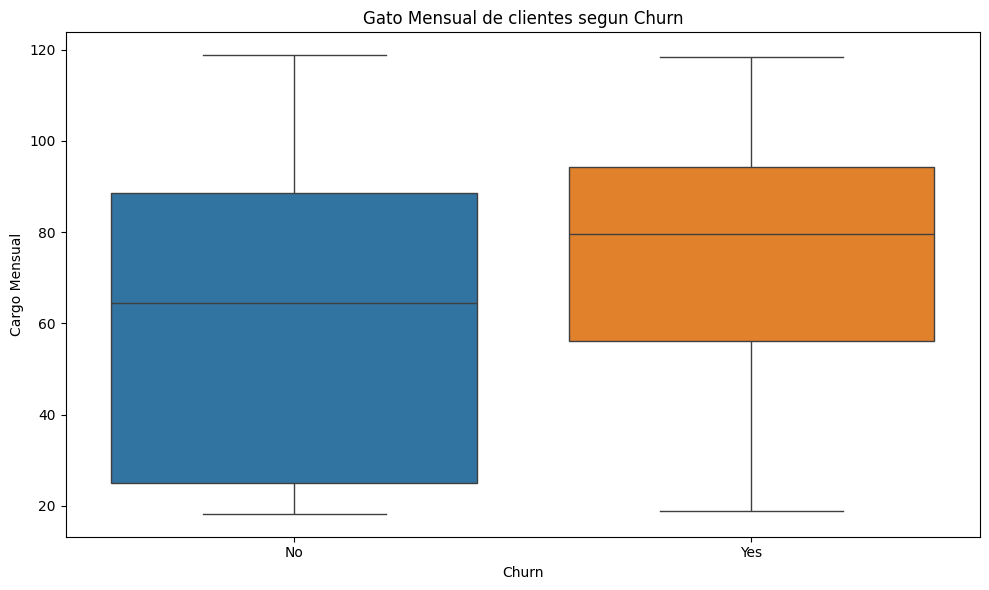

In [34]:
#Vemos relacion entre churn y pagos mensuales
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn')
plt.title("Gato Mensual de clientes segun Churn")
plt.xlabel("Churn")
plt.ylabel("Cargo Mensual")
plt.tight_layout()
plt.show()

---
* SIn embargo, tambien se observa que los clientes que se salen de la compañia, tienen gastos mensuales mas elevados que aquellos que se quedan
---

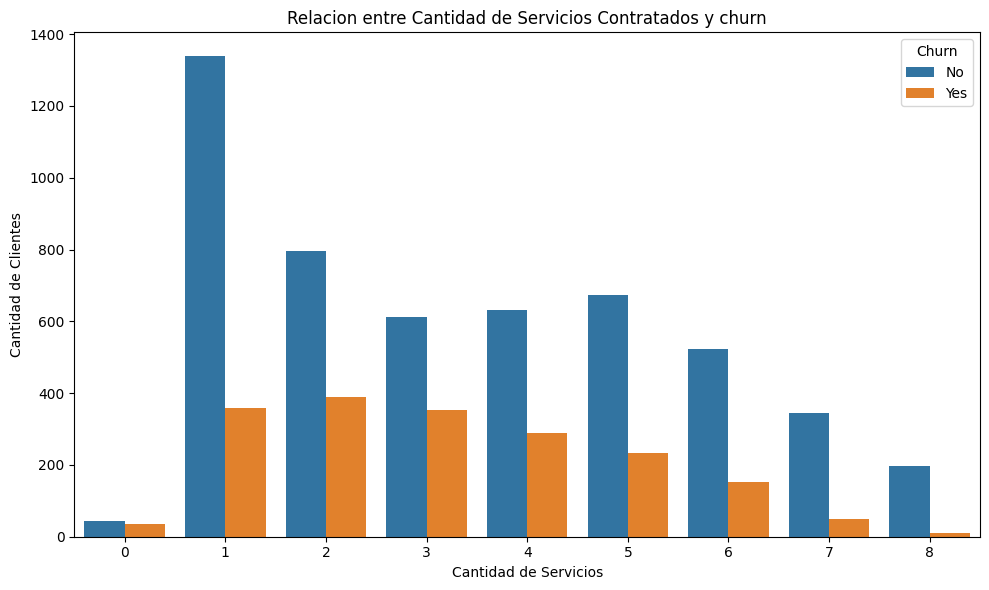

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(x='CantServicios', hue='Churn', data=df)
plt.title('Relacion entre Cantidad de Servicios Contratados y churn')
plt.xlabel("Cantidad de Servicios")
plt.ylabel("Cantidad de Clientes")
plt.tight_layout()
plt.show()

---
* Vemos tambien que los clientes que contratan entre 2 a 4 servicios, son los que proporcionalmente tienen los cliente 'Churn' mas altos
---

## Posibles recomendaciones

* Un precio mas bajo el primer año a nuevos clientes
* Crear packs entre 1 a 4 servicios que pueda ser mas economico, que permita retener el cliente mas tiempo